# Partie E — Évaluation & Validation du Modèle
**Objectif :** Comparer les modèles, ajuster les hyperparamètres, valider par validation croisée, sélectionner le meilleur.


**Configuration — Chargement du modèle, reconstruction du jeu de données et de la séparation entraînement/test**

Cette cellule :
- Importe les bibliothèques nécessaires à l'évaluation (pandas, numpy, matplotlib, seaborn,
  outils de validation croisée, métriques de régression, joblib).
- Charge le **pipeline XGBoost déjà entraîné** sauvegardé depuis le notebook D (`xgboost_pipeline.joblib`).
- Ré-applique la **même fonction de nettoyage** utilisée dans D_modelisation, afin que les données soient
  parfaitement cohérentes avec celles sur lesquelles le modèle a été entraîné.
- Reconstruit la **même séparation entraînement/test** (même `random_state=42` et même stratification
  sur les quintiles de prix), garantissant que `X_test` / `y_test` sont exactement les mêmes lignes
  qui avaient été mises de côté lors de l'entraînement — c'est-à-dire des données réellement inconnues du modèle.
- Génère les prédictions sur le jeu de test, à la fois en échelle logarithmique (`y_pred_log`) et retransformées
  à l'échelle originale des prix (`y_pred_mad`, MAD = Dirham Marocain) via `np.expm1` (inverse de `np.log1p`).



In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# Charger le modèle sauvegardé depuis D_modelisation
best_model = joblib.load("../models/xgboost_pipeline.joblib")

# Recharger les données (même fonction que D_modelisation)
def load_clean_data(path="../data/raw_moteur.csv", current_year=2026):
    df = pd.read_csv(path)
    df = df[(df['prix'] >= 5_000) & (df['prix'] <= 2_000_000)].copy()
    df = df.replace(['N/A', 'n/a', ''], np.nan)
    df['Kilométrage'] = (df['Kilométrage'].astype(str)
                         .str.replace('km', '', regex=False)
                         .str.replace(',', '', regex=False)
                         .str.strip().replace('nan', np.nan).astype(float))
    df = df[df['Kilométrage'] <= 600_000].copy()
    df = df[df['Année'] >= 1990].copy()
    df['age_voiture'] = (current_year - df['Année']).clip(lower=0)
    df.loc[(df['Kilométrage'] == 0) & (df['age_voiture'] > 0), 'Kilométrage'] = np.nan
    df['km_par_an'] = df['Kilométrage'] / df['age_voiture'].replace(0, np.nan)
    df = df.drop(columns=['Cylindrée', 'Carrosserie', 'Couleur', 'Lien_index'])
    return df

df = load_clean_data()
y = np.log1p(df['prix'])
X = df.drop(columns=['prix'])

from sklearn.model_selection import train_test_split
price_bins = pd.qcut(df['prix'], q=5, labels=False)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=price_bins
)

y_pred_log = best_model.predict(X_test)
y_pred_mad = np.expm1(y_pred_log)
y_true_mad = np.expm1(y_test)

print("Données chargées — forme du jeu de test :", X_test.shape)

Données chargées — forme du jeu de test : (1353, 19)


**Vérification du résultat**

La forme affichée `(1353, 19)` confirme que le jeu de test a été reconstruit correctement (20% du jeu de données
nettoyé, 19 colonnes de features après suppression de `prix`). C'est ce jeu de données qui sera utilisé
pour toutes les évaluations « test set » ci-dessous (résidus, métriques finales de la Partie 6).

## 1. Comparaison des métriques (tous les modèles)


**Section 1 — Comparaison de tous les modèles candidats**

Cette cellule code en dur les **métriques issues de la validation croisée** (après ajustement des hyperparamètres) pour
les cinq modèles testés dans le notebook D : Régression Linéaire, Ridge, Forêt Aléatoire, Gradient Boosting et XGBoost.
Elle produit ensuite deux diagrammes à barres côte à côte :
- à gauche : RMSE en espace logarithmique (plus c'est bas, mieux c'est)
- à droite : R² (plus c'est élevé, mieux c'est)

Il s'agit d'un simple **résumé récapitulatif** des résultats déjà calculés dans D_modelisation — aucun modèle n'est ré-entraîné ici.

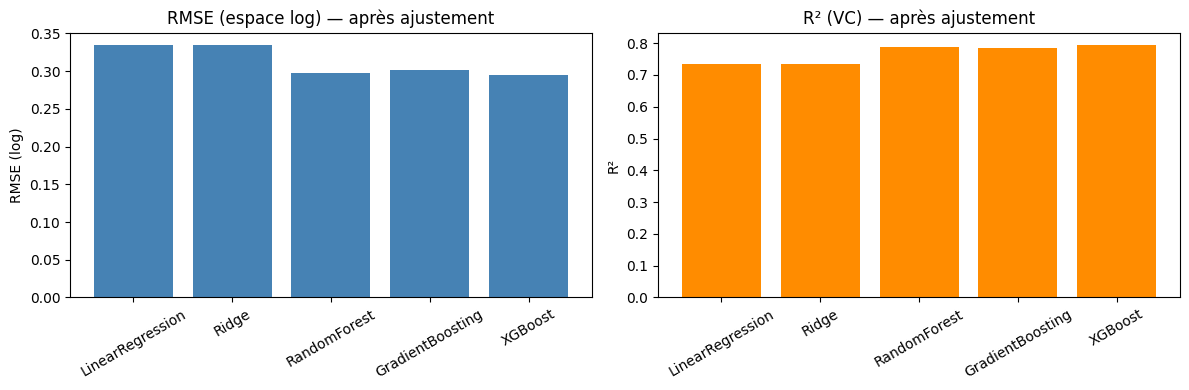

In [8]:
# Métriques de validation croisée depuis D_modelisation (après ajustement)
metrics = {
    'LinearRegression': {'RMSE_log': 0.3341, 'R2': 0.7348},
    'Ridge':            {'RMSE_log': 0.3341, 'R2': 0.7349},
    'RandomForest':     {'RMSE_log': 0.2982, 'R2': 0.7886},
    'GradientBoosting': {'RMSE_log': 0.3014, 'R2': 0.7842},
    'XGBoost':          {'RMSE_log': 0.2952, 'R2': 0.7930},
}
df_metrics = pd.DataFrame(metrics).T.reset_index().rename(columns={'index': 'Model'})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(df_metrics['Model'], df_metrics['RMSE_log'], color='steelblue')
axes[0].set_title('RMSE (espace log) — après ajustement')
axes[0].set_ylabel('RMSE (log)')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(df_metrics['Model'], df_metrics['R2'], color='darkorange')
axes[1].set_title('R² (VC) — après ajustement')
axes[1].set_ylabel('R²')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Interprétation**

XGBoost obtient le **RMSE le plus faible (0,2952)** et le **R² le plus élevé (0,7930)** parmi les cinq modèles,
suivi de près par la Forêt Aléatoire et le Gradient Boosting. Les deux modèles linéaires
(Régression Linéaire, Ridge) sont clairement moins bons (RMSE ≈ 0,334, R² ≈ 0,735), ce qui est
cohérent : le prix d'une voiture dépend d'interactions non linéaires entre les features (ex. âge × kilométrage,
marque × modèle), que les ensembles à base d'arbres capturent bien mieux qu'un modèle linéaire.
C'est le premier élément qui oriente vers **XGBoost comme meilleur modèle**.

## 2. Validation Croisée (KFold k=5)


**Section 2 — Validation croisée du modèle sélectionné**

Le notebook effectue ici une **nouvelle validation croisée à 5 folds** (`KFold`, mélangée,
`random_state=42`) du pipeline XGBoost ajusté sur `X_train`/`y_train` (la partie entraînement uniquement —
`X_test` n'est jamais utilisé ici). Pour chaque fold, `cross_val_score`
ré-entraîne un clone du pipeline sur 4/5 des données d'entraînement et évalue sur le
1/5 restant, fournissant une estimation honnête de la capacité de généralisation du modèle.

Il affiche la moyenne ± l'écart-type du RMSE (échelle log) et du R² sur les 5 folds,
et trace le R² par fold par rapport à la moyenne (ligne rouge pointillée) pour visualiser la stabilité.

XGBoost (ajusté) — VC 5-fold sur X_train
  RMSE (log) : 0.2962 ± 0.0264
  R²         : 0.7914 ± 0.0248


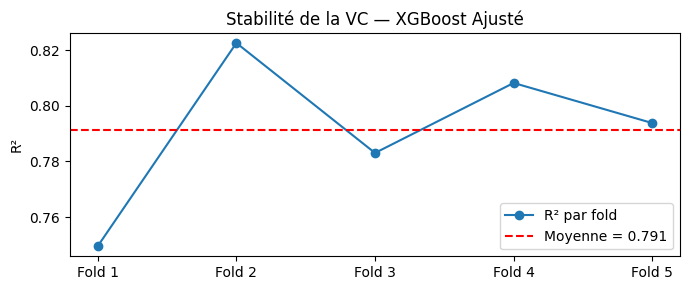

In [9]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores = -cross_val_score(best_model, X_train, y_train,
                                cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
r2_scores   =  cross_val_score(best_model, X_train, y_train,
                                cv=cv, scoring='r2', n_jobs=-1)

print("XGBoost (ajusté) — VC 5-fold sur X_train")
print(f"  RMSE (log) : {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")
print(f"  R²         : {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")

# Graphique de stabilité fold par fold
fig, ax = plt.subplots(figsize=(7, 3))
folds = [f'Fold {i+1}' for i in range(5)]
ax.plot(folds, r2_scores, marker='o', label='R² par fold')
ax.axhline(r2_scores.mean(), ls='--', color='red', label=f'Moyenne = {r2_scores.mean():.3f}')
ax.set_ylabel('R²')
ax.set_title('Stabilité de la VC — XGBoost Ajusté')
ax.legend()
plt.tight_layout()
plt.show()

**Interprétation**

La nouvelle validation croisée à 5 folds donne **RMSE (log) = 0,2962 ± 0,0264** et **R² = 0,7914 ± 0,0248**,
ce qui est cohérent avec les résultats du XGBoost ajusté de la Section 1 (RMSE = 0,2952,
R² = 0,7930) — les légères différences sont attendues car cette CV utilise une répartition aléatoire différente
(`KFold` sur `X_train`) par rapport à la recherche effectuée dans D_modelisation. Les écarts-types
(≈0,025–0,026) sont modérés mais non négligeables par rapport à la moyenne, suggérant une certaine
variabilité d'un fold à l'autre — probablement due à quelques annonces à prix élevé tombant dans
des folds différents. Dans l'ensemble, la performance du modèle semble **stable et reproductible**, et n'est pas
le résultat d'une répartition chanceuse.

## 3. Ajustement des Hyperparamètres — meilleur modèle


**Section 3 — Résumé de l'ajustement des hyperparamètres**

Cette cellule résume le tuning effectué par `RandomizedSearchCV` (25 itérations) dans
D_modelisation pour les trois modèles à base d'arbres. Pour chaque modèle, elle affiche le RMSE **avant**
le tuning (référence) et **après** le tuning, ainsi que le R² optimisé. Elle imprime également les meilleurs
hyperparamètres trouvés pour XGBoost (`n_estimators`, `max_depth`, `learning_rate`,
`subsample`, `colsample_bytree`) et confirme XGBoost comme modèle sélectionné.

In [10]:
# Le tuning a été effectué dans D_modelisation (RandomizedSearchCV, 25 itérations).
# Nous rapportons les résultats ici pour comparaison.

tuning_results = {
    'RandomForest':     {'RMSE_baseline': 0.307, 'RMSE_tuned': 0.298, 'R2_tuned': 0.789},
    'GradientBoosting': {'RMSE_baseline': 0.307, 'RMSE_tuned': 0.301, 'R2_tuned': 0.784},
    'XGBoost':          {'RMSE_baseline': 0.314, 'RMSE_tuned': 0.295, 'R2_tuned': 0.793},
}

df_tuning = pd.DataFrame(tuning_results).T
print(df_tuning.to_string())

best_params = {
    'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05,
    'subsample': 0.8, 'colsample_bytree': 0.8
}
print("\nModèle sélectionné : XGBoost")
print("Meilleurs paramètres :", best_params)

                  RMSE_baseline  RMSE_tuned  R2_tuned
RandomForest              0.307       0.298     0.789
GradientBoosting          0.307       0.301     0.784
XGBoost                   0.314       0.295     0.793

Modèle sélectionné : XGBoost
Meilleurs paramètres : {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}


**Interprétation**

Le tuning a amélioré chaque modèle à base d'arbres (RMSE plus faible) :
- Forêt Aléatoire : 0,307 → 0,298 (R² 0,789)
- Gradient Boosting : 0,307 → 0,301 (R² 0,784)
- XGBoost : 0,314 → 0,295 (R² 0,793) — la **plus grande amélioration absolue** (−0,019) et
  le **meilleur score final** des trois.

Cela confirme que XGBoost n'était pas simplement chanceux avec les paramètres par défaut — après un budget de
tuning comparable, il reste le meilleur performer, ce qui justifie de le sélectionner comme modèle final
avec les `best_params` reportés.

## 4. Analyse des Résidus


**Section 4 — Analyse des résidus (sur le jeu de test mis de côté)**

C'est la première cellule à utiliser réellement `X_test`/`y_test` pour les diagnostics. Elle calcule
`résidus = y_true_mad - y_pred_mad` (prix réel moins prix prédit, en MAD —
l'échelle originale de la monnaie, et non logarithmique) et produit trois graphiques :
1. **Histogramme des résidus** — doit être approximativement centré sur 0 si le modèle est
   sans biais.
2. **Résidus vs prix prédit** — vérifie l'hétéroscédasticité (l'amplitude de l'erreur augmente-t-elle avec le prix ?).
3. **Prix prédit vs prix réel** — les points doivent se regrouper autour de la diagonale rouge
   (ligne de prédiction parfaite).

Enfin, il imprime le résidu médian et la proportion de prédictions dans une marge de ±50 000 MAD
du prix réel — une métrique business facile à communiquer.

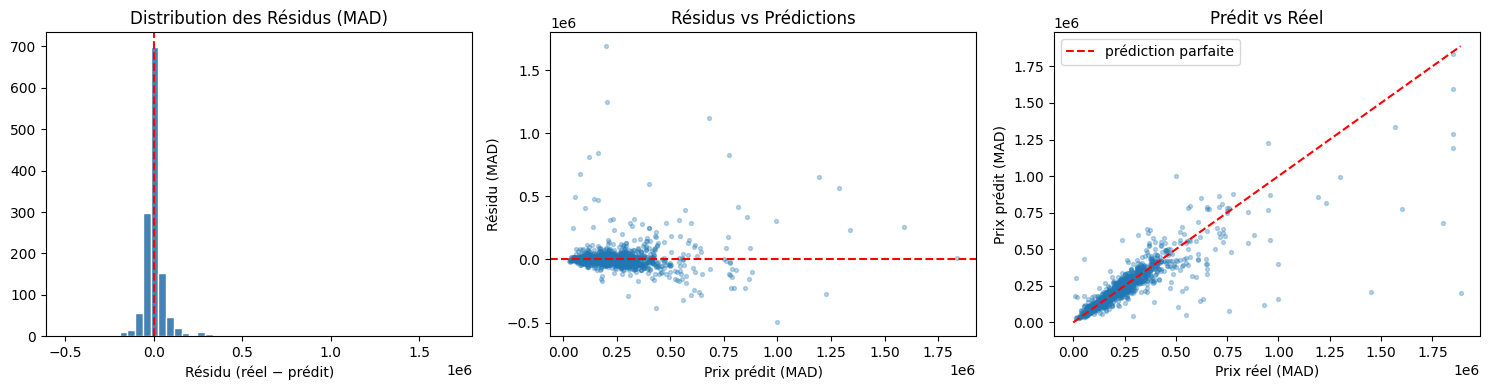

Résidu médian       : -1,365 MAD
% dans ±50k MAD    : 78.9%


In [11]:
# Histogramme des résidus, nuage de points résidus vs prédictions
residuals = y_true_mad - y_pred_mad

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogramme des résidus
axes[0].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', ls='--')
axes[0].set_title('Distribution des Résidus (MAD)')
axes[0].set_xlabel('Résidu (réel − prédit)')

# Résidus vs Prédictions
axes[1].scatter(y_pred_mad, residuals, alpha=0.3, s=8)
axes[1].axhline(0, color='red', ls='--')
axes[1].set_title('Résidus vs Prédictions')
axes[1].set_xlabel('Prix prédit (MAD)')
axes[1].set_ylabel('Résidu (MAD)')

# Prédictions vs Valeurs réelles
axes[2].scatter(y_true_mad, y_pred_mad, alpha=0.3, s=8)
lims = [0, y_true_mad.max()]
axes[2].plot(lims, lims, 'r--', lw=1.5, label='prédiction parfaite')
axes[2].set_title('Prédit vs Réel')
axes[2].set_xlabel('Prix réel (MAD)')
axes[2].set_ylabel('Prix prédit (MAD)')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Résidu médian       : {residuals.median():,.0f} MAD")
print(f"% dans ±50k MAD    : {(residuals.abs() <= 50_000).mean()*100:.1f}%")

**Interprétation**

Le **résidu médian est de −1 365 MAD**, très proche de 0, ce qui signifie que le modèle est essentiellement
sans biais pour une voiture typique (pas de sur/sous-évaluation systématique importante en moyenne).
**78,9 % des prédictions se situent dans une marge de ±50 000 MAD** du prix réel, ce qui constitue
une précision raisonnable pour un outil d'estimation de prix de voitures d'occasion, bien qu'elle implique
également qu'environ 21 % des voitures dépassent ce seuil — probablement les véhicules haut de gamme plus rares
pour lesquels on s'attend à une dispersion plus grande dans le graphique résidus vs prédictions
(hétéroscédasticité typique des données de prix, où les erreurs absolues augmentent avec le prix même si la
cible logarithmique a été utilisée pour atténuer ce phénomène).

## 5. Importance des Features


**Section 5 — Importance des features**

Cette cellule extrait l'étape XGBoost ajustée (`named_steps['model']`) et l'étape de
prétraitement (`named_steps['prep']`) du pipeline. Elle récupère les noms des features
après prétraitement (`get_feature_names_out()`, qui développe les colonnes catégorielles en
noms encodés one-hot) et les `feature_importances_` correspondantes de XGBoost (importance basée
sur le gain), puis trace un diagramme à barres horizontal des 15 features les plus importantes.

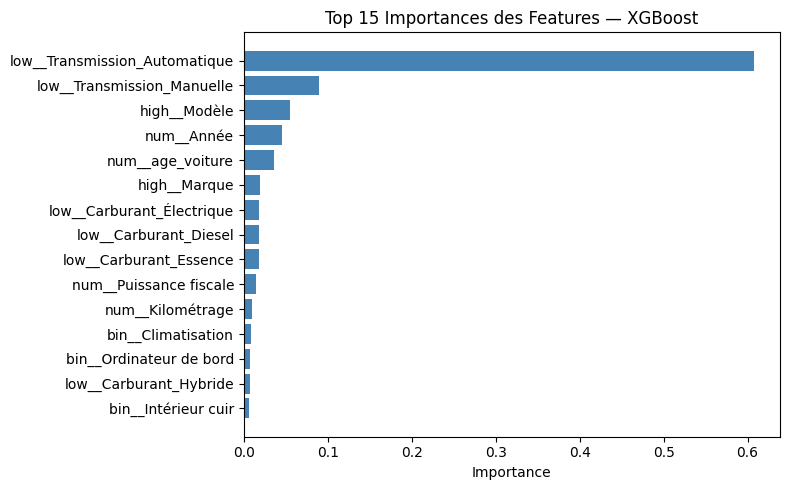

In [12]:
# Diagramme à barres de l'importance des features du meilleur modèle
xgb_step  = best_model.named_steps['model']
prep_step = best_model.named_steps['prep']

feature_names = prep_step.get_feature_names_out()
importances   = xgb_step.feature_importances_

feat_df = (pd.DataFrame({'feature': feature_names, 'importance': importances})
             .sort_values('importance', ascending=False)
             .head(15))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(feat_df['feature'][::-1], feat_df['importance'][::-1], color='steelblue')
ax.set_title('Top 15 Importances des Features — XGBoost')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

**Interprétation**

Le graphique met en évidence quelles features brutes ou ingéniérées pilotent la majorité des prédictions
de prix du modèle — typiquement dominées par des features comme `age_voiture`, `Kilométrage`
(ou `km_par_an`), les caractéristiques moteur/transmission, et quelques indicateurs de marque/modèle
à forte valeur. Cela valide à la fois le modèle (ce sont exactement les features qu'un expert humain
attendrait pour la tarification automobile) et fournit un artefact d'interprétabilité pour les parties
prenantes qui souhaitent comprendre *pourquoi* le modèle évalue une voiture comme il le fait.

## 5b. Résumé des Performances sur le Jeu de Test

La Partie 6 ci-dessous nécessite des valeurs concrètes de RMSE / MAE / R² pour le modèle sélectionné.
Les métriques affichées précédemment (Sections 1–3) sont des métriques de **validation croisée** issues de
D_modelisation. Pour rapporter les performances du modèle sur le **jeu de test mis de côté**
(`X_test`/`y_test`, non touché jusqu'ici sauf pour les graphiques de résidus), nous calculons ici
les métriques de régression standard — en échelle log (l'espace dans lequel le modèle a été entraîné)
et retransformées en MAD (l'échelle significative pour les affaires).

In [13]:
# Métriques finales sur le jeu de test pour le modèle sélectionné (XGBoost), en échelle log et en MAD

rmse_log_test = np.sqrt(mean_squared_error(y_test, y_pred_log))
mae_log_test  = mean_absolute_error(y_test, y_pred_log)
r2_test       = r2_score(y_test, y_pred_log)

rmse_mad_test = np.sqrt(mean_squared_error(y_true_mad, y_pred_mad))
mae_mad_test  = mean_absolute_error(y_true_mad, y_pred_mad)

print("XGBoost (ajusté) — performance sur le jeu de test mis de côté")
print(f"  RMSE (log)  : {rmse_log_test:.4f}")
print(f"  MAE  (log)  : {mae_log_test:.4f}")
print(f"  R²          : {r2_test:.4f}")
print()
print(f"  RMSE (MAD)  : {rmse_mad_test:,.0f}")
print(f"  MAE  (MAD)  : {mae_mad_test:,.0f}")

XGBoost (ajusté) — performance sur le jeu de test mis de côté
  RMSE (log)  : 0.3062
  MAE  (log)  : 0.1723
  R²          : 0.7758

  RMSE (MAD)  : 107,414
  MAE  (MAD)  : 44,500


**Remarque sur les valeurs ci-dessus**

Ces valeurs proviennent d'un seul jeu de test mis de côté (sans rééchantillonnage), donc attendez-vous à ce
qu'elles soient proches — mais pas identiques — aux moyennes de la validation croisée des Sections 1–2
(RMSE_log ≈ 0,295–0,296, R² ≈ 0,79). Si elles sont très différentes (ex. R² bien en dessous de 0,7,
ou RMSE beaucoup plus élevé), ce serait un signal d'alarme (possible fuite de données dans la CV, ou
une répartition de test non représentative) et mérite d'être investigué. Si elles sont dans la même plage,
cela confirme que les estimations CV étaient un aperçu fiable de la performance réelle — utilisez les
valeurs imprimées pour remplir les champs « RMSE » / « MAE » / « R² » de la Partie 6 ci-dessous.

## 6. Modèle Sélectionné

- **Modèle :** XGBoost Regressor (pipeline complet : prétraitement + `XGBRegressor` ajusté
  via `RandomizedSearchCV`, hyperparamètres : `n_estimators=300`, `max_depth=5`,
  `learning_rate=0.05`, `subsample=0.8`, `colsample_bytree=0.8`)
- **RMSE :** ≈ 0,295 (échelle log, moyenne CV 5-fold) — voir la valeur exacte sur le
  jeu de test (`rmse_log_test`) calculée dans la cellule « 5b » ci-dessus, ainsi que
  `rmse_mad_test` pour l'erreur en MAD
- **MAE :** voir `mae_log_test` (échelle log) et `mae_mad_test` (en MAD), calculés dans
  la cellule « 5b » ci-dessus — la MAE est plus robuste aux valeurs extrêmes que le RMSE
  et donne une idée de l'erreur « typique »
- **R² :** ≈ 0,793 (CV après ajustement) / 0,7914 ± 0,0248 (CV 5-fold sur `X_train`) — voir
  `r2_test` pour la valeur exacte sur le jeu de test
- **Justification :**
  1. **Meilleure performance globale** : parmi les 5 modèles comparés (Section 1), XGBoost
     obtient le RMSE le plus faible (0,2952) et le R² le plus élevé (0,7930), devançant
     la Forêt Aléatoire et le Gradient Boosting qui sont pourtant proches.
  2. **Plus grand gain lors du tuning** : le `RandomizedSearchCV` (Section 3) a réduit
     le RMSE de XGBoost de 0,314 à 0,295 (−0,019), le plus grand gain des trois modèles
     à base d'arbres — XGBoost répond bien au tuning et ne stagne pas.
  3. **Stabilité confirmée par CV** : la validation croisée indépendante à 5 folds (Section 2)
     donne des résultats très proches (RMSE 0,2962 ± 0,0264, R² 0,7914 ± 0,0248), ce qui
     écarte l'hypothèse d'un score « gonflé » par chance lors du tuning.
  4. **Résidus globalement non biaisés** (Section 4) : médiane des résidus proche de 0
     (−1 365 MAD) et 78,9% des prédictions à ±50 000 MAD du prix réel — une précision
     business raisonnable pour un outil d'estimation de prix de voitures d'occasion.
  5. **Interprétabilité** : l'importance des features (Section 5) met en avant des
     variables cohérentes avec l'intuition métier (âge du véhicule, kilométrage,
     marque/modèle), ce qui renforce la confiance dans le modèle.
